In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Just to ignore warnings

import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import uproot
from variables_calculator import variables_calculator

import warnings
warnings.filterwarnings("ignore")

## Signal and noise signal classification

In [2]:
model = keras.models.load_model("/tf/Higgs-Boson-LHC-Collision-Detector/Trials-ANN/ResNet-SnB-Classificator.keras")

In [3]:
# Create the dataframe for validation
sg = pd.read_csv("/tf/Higgs-Boson-LHC-Collision-Detector/Datasets/Signal.csv")
bg = pd.read_csv("/tf/Higgs-Boson-LHC-Collision-Detector/Datasets/Background.csv")

val = pd.concat([sg, bg])
val = val.drop(columns = ["Unnamed: 0"])

# Now we can create the subsets:

X_val = val.drop(columns = ["label"])
y_val = val["label"]

# And we stardardize the data:

scaler = StandardScaler()
X_val = scaler.fit_transform(X_val)

# Check the size
print("Test size:", len(X_val))

Test size: 554161


In [4]:
# And we check the predictions
y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

17318/17318 [==============================] - 55s 3ms/step


In [5]:
real_data = pd.concat([sg, bg])
real_data = real_data.drop(columns = ["Unnamed: 0"])
predicted_data = real_data.drop(columns = ["label"])
predicted_data["label"] = y_pred_classes

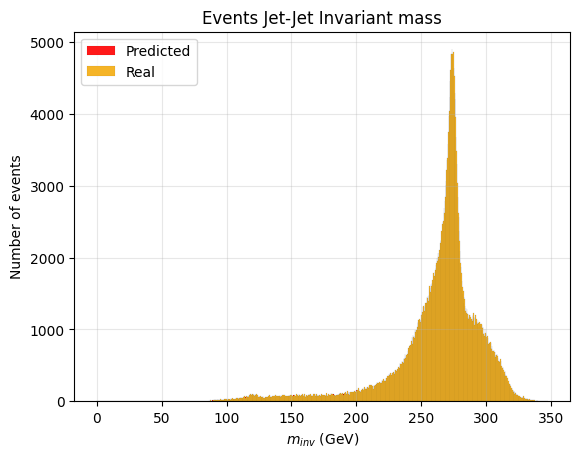

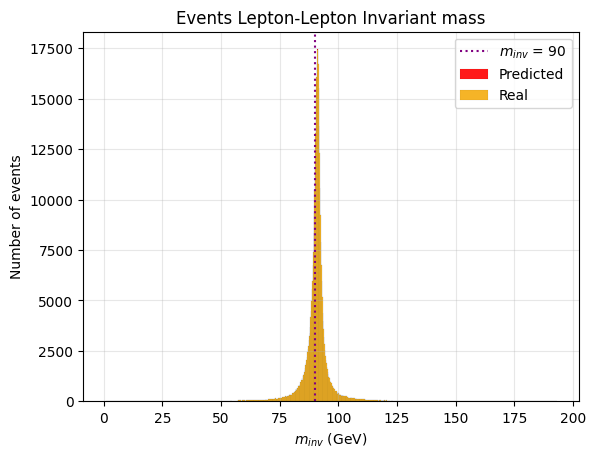

In [6]:
df_predicted_signal = predicted_data[predicted_data["label"] != 0].copy()
df_real_signal = real_data[real_data["label"] != 0].copy()

sns.histplot(df_predicted_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Jet-Jet Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

sns.histplot(df_predicted_signal["DER_mass_lep"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_signal["DER_mass_lep"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.axvline(x = 90, color = "purple", linestyle = ':', label = rf"$m_{{inv}}$ = 90")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Lepton-Lepton Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

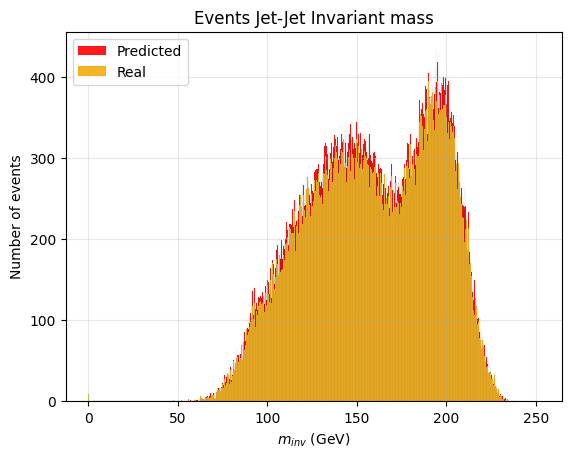

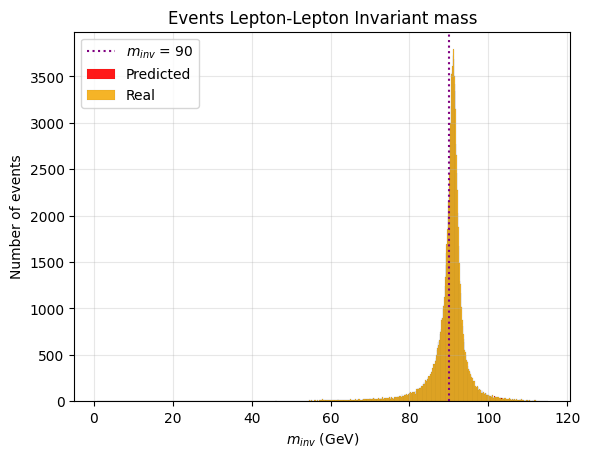

In [7]:
df_predicted_background = predicted_data[predicted_data["label"] == 0].copy()
df_real_background = real_data[real_data["label"] == 0].copy()

sns.histplot(df_predicted_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Jet-Jet Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

sns.histplot(df_predicted_background["DER_mass_lep"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_background["DER_mass_lep"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.axvline(x = 90, color = "purple", linestyle = ':', label = rf"$m_{{inv}}$ = 90")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Lepton-Lepton Invariant mass")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

17318/17318 [==============================] - 53s 3ms/step


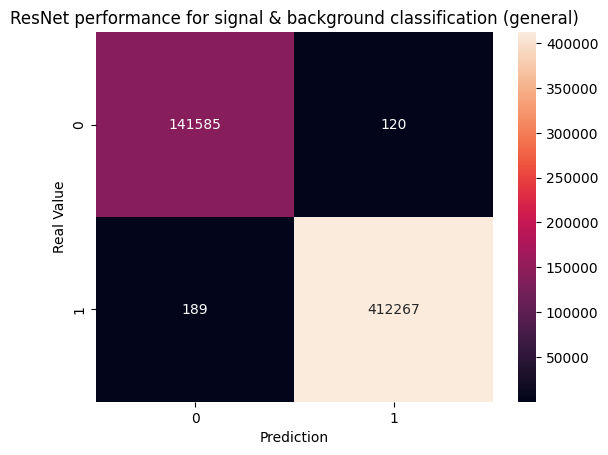

In [8]:
y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

cm = confusion_matrix(y_pred_classes, y_val)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "rocket")
plt.title("ResNet performance for signal & background classification (general)")
plt.xlabel("Prediction")
plt.ylabel("Real Value")
plt.show()

In [9]:
# We check the performance of the validation
loss, accuracy, precision, auc, auc_1 = model.evaluate(X_val, y_val, verbose = 1)

print(f"Test Loss: {loss:}")
print(f"Test Accuracy: {accuracy:}")

17318/17318 [==============================] - 78s 4ms/step - loss: 0.0201 - accuracy: 0.9994 - precision: 0.9995 - auc: 0.9996 - auc_1: 0.9998
Test Loss: 0.020116351544857025
Test Accuracy: 0.9994423985481262


## Higgs signal classification

In [10]:
# Now we check for the Higgs signal
file = "/tf/Higgs-Boson-LHC-Collision-Detector/sigfcc_350.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 0)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

signal = pd.merge(jets_data, lepton_data, on = "event_1")
signal = signal.drop(columns = ["event_1"])

# And the noise
file = "/tf/Higgs-Boson-LHC-Collision-Detector/bgd240zh.root"

data = uproot.open(file)
tree = data["Delphes"]

higgs_b = variables_calculator.inv_m(file, "jet_1", "jet_2", flavor1 = 3, flavor2 = 5)
higgs_b = higgs_b[["pt_1", "pt_2", "eta_1", "eta_2", "phi_1", "phi_2", "event_1", "inv_m"]].copy()
higgs_b.columns = ["PRI_jet_leading_pt", "PRI_jet_subleading_pt", "PRI_jet_leading_eta", "PRI_jet_subleading_eta", "PRI_jet_leading_phi",
                  "PRI_jet_subleading_phi", "event_1", "DER_mass_jet_jet"]

PRI_jet_num = variables_calculator.PRI_jet_num(file)
PRI_jet_all = variables_calculator.PRI_jet_all_pt(file)
met = variables_calculator.met(file)

jets_data = pd.merge(PRI_jet_all, PRI_jet_num, on = "event_1")
jets_data = pd.merge(jets_data, met, on = "event_1")
jets_data = pd.merge(jets_data, higgs_b, on = "event_1")

jets_data["label"] = np.full(len(jets_data), 1)

muon_data = variables_calculator.inv_m(file, "muon", "muon")
electron_data = variables_calculator.inv_m(file, "electron", "electron")
lepton_data = pd.concat([muon_data, electron_data])

lepton_data = lepton_data[["event_1", "inv_m"]].copy()
lepton_data.columns = ["event_1", "DER_mass_lep"]

noise = pd.merge(jets_data, lepton_data, on = "event_1")
noise = noise.drop(columns = ["event_1"])

val = pd.concat([signal, noise])

# Now we can create the subsets:
X_val = val.drop(columns = ["label"])
y_val = val["label"]

# And we stardardize the data:

scaler = StandardScaler()

X_val = scaler.fit_transform(X_val)

# Check the sizes
print("Validation size:", len(X_val))

Validation size: 79533


2486/2486 [==============================] - 9s 3ms/step


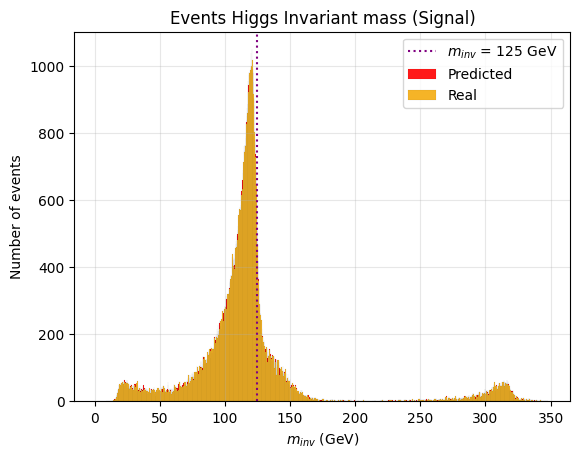

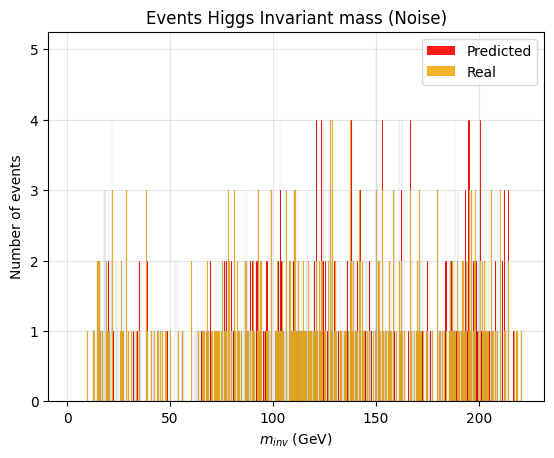

In [11]:
# Check the predictions
model = keras.models.load_model("/tf/Higgs-Boson-LHC-Collision-Detector/Trials-ANN/ResNet-SnB-Higgs_B-Classificator.keras")

y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

real_data = val
order = ['PRI_jet_all_pt', 'PRI_jet_num', 'PRI_met', 'PRI_met_phi',
       'PRI_jet_leading_pt', 'PRI_jet_subleading_pt', 'PRI_jet_leading_eta',
       'PRI_jet_subleading_eta', 'PRI_jet_leading_phi',
       'PRI_jet_subleading_phi', 'DER_mass_jet_jet', 'label', 'DER_mass_lep']
real_data = real_data.reindex(columns = order)
predicted_data = real_data.drop(columns = ["label"])
predicted_data["label"] = y_pred_classes

df_predicted_signal = predicted_data[predicted_data["label"] != 1].copy()
df_real_signal = real_data[real_data["label"] != 1].copy()

df_predicted_background = predicted_data[predicted_data["label"] == 1].copy()
df_real_background = real_data[real_data["label"] == 1].copy()

sns.histplot(df_predicted_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_signal["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.axvline(x = 125, color = "purple", linestyle = ':', label = rf"$m_{{inv}}$ = 125 GeV")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Higgs Invariant mass (Signal)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

sns.histplot(df_predicted_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Predicted", alpha = 0.9, color = "red")
sns.histplot(df_real_background["DER_mass_jet_jet"], bins = 1000, kde = False, label = "Real", alpha = 1, color = "#F5B427")
plt.xlabel(r"$m_{inv}$ (GeV)")
plt.ylabel("Number of events")
plt.title(r"Events Higgs Invariant mass (Noise)")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

2486/2486 [==============================] - 9s 3ms/step


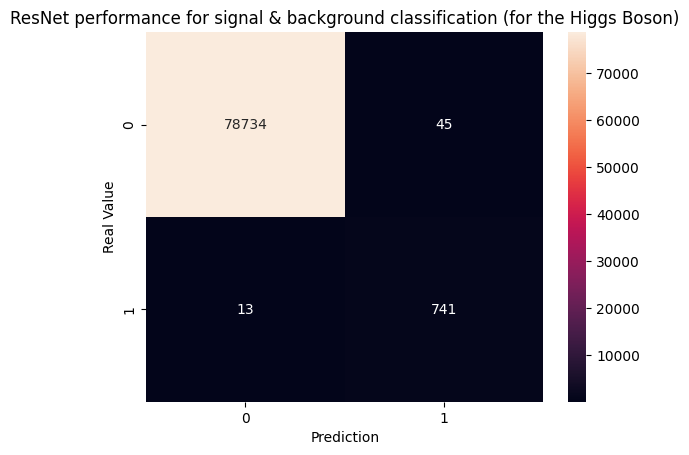

In [12]:
y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32")

cm = confusion_matrix(y_pred_classes, y_val)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "rocket")
plt.title("ResNet performance for signal & background classification (for the Higgs Boson)")
plt.xlabel("Prediction")
plt.ylabel("Real Value")
plt.show()

In [13]:
loss, accuracy, precision, auc, auc_1 = model.evaluate(X_val, y_val, verbose = 1)

print(f"Test Loss: {loss:}")
print(f"Test Accuracy: {accuracy:}")

2486/2486 [==============================] - 13s 5ms/step - loss: 0.0042 - accuracy: 0.9993 - precision: 0.9828 - auc: 0.9966 - auc_1: 0.9836   
Test Loss: 0.004187857732176781
Test Accuracy: 0.9992707371711731
